# Audio Inference Explorer (On-the-fly Mel)

Workflow:
1. Pick a trained model bundle (`audio_pca_svm_model.joblib`)
2. Pick a WAV file
3. Build mel from WAV using the model's saved mel config
4. Display mel spectrogram
5. Play WAV
6. Run inference


In [12]:
from pathlib import Path
import sys
import json

import matplotlib.pyplot as plt
from IPython.display import Audio, display

# Find repo root by walking up until go.mod exists
REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'go.mod').exists():
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / 'python'))

from ml.train.audio_pca_svm import (
    load_audio_pca_svm_bundle,
    predict_audio_pca_svm,
    _load_mel_input,
)

print('Repo root:', REPO_ROOT)


Repo root: /home/cbaguilar/work/water/svwatergo


In [58]:
# Update paths as needed
ON = 'data/raw/Pryor_Farms_1_2026-02-25_wav/camera=Pryor_Farms_1/date=2026-02-25/Pryor_Farms_1_2026-02-25T22-21-41.521000Z_chunk=002430.wav'
OFF = 'data/raw/Pryor_Farms_1_2026-02-25_wav/camera=Pryor_Farms_1/date=2026-02-25/Pryor_Farms_1_2026-02-25T15-15-32.627000Z_chunk=000049.wav'
DELIVERY = 'data/raw/Pryor_Farms_1_2026-02-25_wav/camera=Pryor_Farms_1/date=2026-02-25/Pryor_Farms_1_2026-02-25T17-50-10.520000Z_chunk=000949.wav'
STARTUP = 'data/raw/Pryor_Farms_1_2026-02-25_wav/camera=Pryor_Farms_1/date=2026-02-25/Pryor_Farms_1_2026-02-25T22-07-45.525000Z_chunk=002354.wav'

BR = '/run/media/cbaguilar/T7/audio_data/bluerock/bluerock_1751681972.306009.wav'
BR_SHUTDOWN = '/run/media/cbaguilar/T7/audio_data/bluerock/bluerock_1751642771.56249.wav'
MODEL_PATH = REPO_ROOT / 'data/checkpoints/ropumprun_on_pca_svm_Pryor_Farms_1_2026-02-25_10s/audio_pca_svm_model.joblib'
WAV_PATH = Path(BR_SHUTDOWN) #REPO_ROOT / STARTUP

print('MODEL_PATH:', MODEL_PATH)
print('WAV_PATH  :', WAV_PATH)

if not MODEL_PATH.exists():
    raise FileNotFoundError(f'Model not found: {MODEL_PATH}')
if not WAV_PATH.exists():
    raise FileNotFoundError(f'WAV not found: {WAV_PATH}')


MODEL_PATH: /home/cbaguilar/work/water/svwatergo/data/checkpoints/ropumprun_on_pca_svm_Pryor_Farms_1_2026-02-25_10s/audio_pca_svm_model.joblib
WAV_PATH  : /run/media/cbaguilar/T7/audio_data/bluerock/bluerock_1751642771.56249.wav


Task      : binary
Mel shape : (64, 622)
Mel config: {
  "sample_rate": 16000,
  "mono": true,
  "target_seconds": 10.0,
  "n_fft": 1024,
  "win_length": 1024,
  "hop_length": 256,
  "n_mels": 64,
  "fmin": 20.0,
  "fmax": 8000.0,
  "power": 2.0,
  "log_eps": 1e-10,
  "to_db": false
}


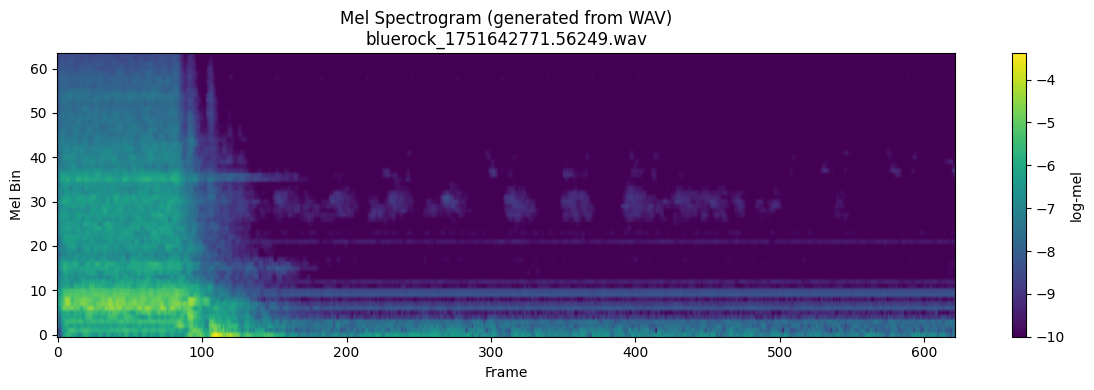

In [59]:
bundle = load_audio_pca_svm_bundle(MODEL_PATH)
mel = _load_mel_input(bundle=bundle, wav_path=WAV_PATH)

print('Task      :', bundle.get('task'))
print('Mel shape :', mel.shape)
print('Mel config:', json.dumps(bundle.get('mel_config', {}), indent=2))

plt.figure(figsize=(12, 4))
plt.imshow(mel, origin='lower', aspect='auto')
plt.title(f'Mel Spectrogram (generated from WAV)\n{WAV_PATH.name}')
plt.xlabel('Frame')
plt.ylabel('Mel Bin')
plt.colorbar(label='log-mel')
plt.tight_layout()
plt.show()


In [61]:
display(Audio(filename=str(WAV_PATH)))


In [62]:
result = predict_audio_pca_svm(MODEL_PATH, wav_path=WAV_PATH)
print(json.dumps(result, indent=2, sort_keys=True))


{
  "mel_shape_used": [
    64,
    622
  ],
  "pca_projection": [
    -94.92137908935547,
    103.40251159667969,
    257.68426513671875,
    47.456825256347656,
    187.24356079101562,
    -40.19593048095703,
    184.60476684570312,
    -0.35184431076049805
  ],
  "positive_label": "on",
  "predicted_index": 0,
  "predicted_label": "negative",
  "probabilities": [
    0.9895159534921899,
    0.010484046507810261
  ],
  "score_positive": 0.010484046507810261,
  "task": "binary"
}
